In [4]:
!pip uninstall -y torch torchvision
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126



Looking in indexes: https://download.pytorch.org/whl/cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 32.2 MB/s eta 0:00:000:00:010:00:01:02
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 35.9 MB/s eta 0:00:00m eta 0:00:010:01:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 43.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 38.8 MB/s eta 0:00:00m eta 0:00:010:01:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 43.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 42.7 MB/s eta 0:00:0031m43.5 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 38.0 MB/s eta 0:00:00 MB/s eta 0:00:01:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 39.1 MB/s eta 0:00:00 MB/s eta 0:00:01:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 MB 38.8 MB/s eta 0:00:000:00:010:00:01:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.7/19.7 MB 43.0 MB/s eta 0:00:

In [63]:
import torch
from torch import  nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import torchvision
from torchvision import transforms
import urllib.request
from matplotlib.pyplot import imshow
from torch.utils.data import  *
from tqdm import tqdm
import time
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
import seaborn as sns
import random
import matplotlib.pyplot as plt
from collections import defaultdict

In [64]:
# This is from ChatGPT

# Define transforms (convert to tensor + normalize)
transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4), 
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load CIFAR-10
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

# Example: get one batch
images, labels = next(iter(trainloader))
print(images.shape)  # (32, 3, 32, 32)

torch.Size([32, 3, 32, 32])


In [65]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [66]:
'''
(a) Display at least 10 random images with their labels.
(b) Report the number of training images and test images.
(c) Determine whether the dataset is balanced across classes.
(d) Briefly discuss which classes might be visually difficult to distinguish.'''

'\n(a) Display at least 10 random images with their labels.\n(b) Report the number of training images and test images.\n(c) Determine whether the dataset is balanced across classes.\n(d) Briefly discuss which classes might be visually difficult to distinguish.'

In [67]:
print('Train set size')
print(len(trainset))
print('Test set size')
print(len(testset))


Train set size
50000
Test set size
10000


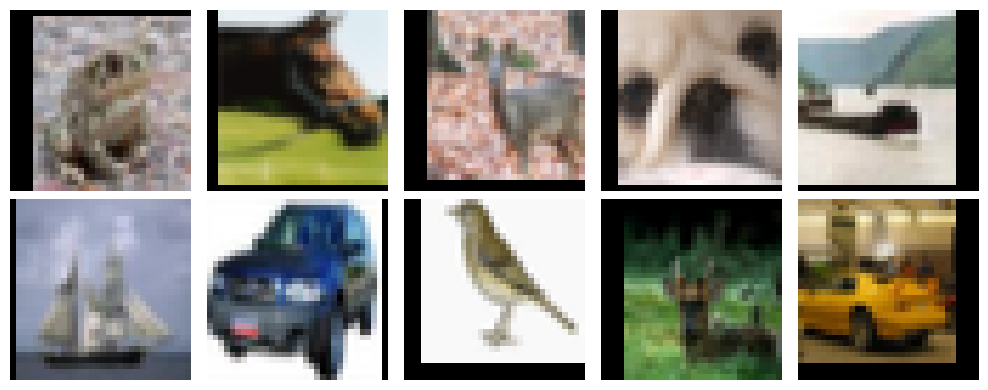

In [68]:
samples = random.sample(range(len(trainset)), 10)

plt.figure(figsize=(10, 4))

for i, idx in enumerate(samples):
    img, label = trainset[idx]
    
    # Convert from tensor to numpy and unnormalize
    img = img / 2 + 0.5  # undo normalization
    img = img.permute(1, 2, 0).numpy()
    
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [69]:
classes = trainset.classes
print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [70]:
labels = defaultdict(int)
print(trainset[0][1])
for img, label in trainset:
    labels[label] += 1
print(labels)
# (c) This is a balanced dataset
# (d) I would expect the classifier to have difficulty with automobiles and trucks, maybe with deer/horse as well

6
defaultdict(<class 'int'>, {6: 5000, 9: 5000, 4: 5000, 1: 5000, 2: 5000, 7: 5000, 8: 5000, 3: 5000, 5: 5000, 0: 5000})


In [71]:
def run_epoch(model, optimizer, data_loader, loss_func, device, results, score_funcs, prefix="", desc=None):
    running_loss = []
    y_true = []
    y_pred = []
    start = time.time()
    for inputs, labels in tqdm(data_loader, desc=desc, leave=False):
        #Move the batch to the device we are using.
        inputs = inputs.to(device)
        labels = labels.to(device)

        y_hat = model(inputs) #this just computed f_Θ(x(i))
        # Compute loss.
        loss = loss_func(y_hat, labels)

        if model.training: #check the flag
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        #Now we are just grabbing some information we would like to have
        running_loss.append(loss.item())

        if len(score_funcs) > 0 and isinstance(labels, torch.Tensor):
            #moving labels & predictions back to CPU for computing / storing predictions
            labels = labels.detach().cpu().numpy() # we have this info in the slides. Please remember why I am detaching
            y_hat = y_hat.detach().cpu().numpy()
            #add to predictions so far
            y_true.extend(labels.tolist())
            y_pred.extend(y_hat.tolist())
    #end training epoch
    end = time.time()

    y_pred = np.asarray(y_pred)
    if len(y_pred.shape) == 2 and y_pred.shape[1] > 1: #We have a classification problem, convert to labels
        y_pred = np.argmax(y_pred, axis=1)
    #Else, we assume we are working on a regression problem

    results[prefix + " loss"].append( np.mean(running_loss) )
    for name, score_func in score_funcs.items():
        try:
            results[prefix + " " + name].append( score_func(y_true, y_pred) )
        except:
            results[prefix + " " + name].append(float("NaN"))
    return end-start

In [72]:
def train_simple_network(model, loss_func, train_loader, test_loader=None, score_funcs=None,epochs=50, device="cpu", checkpoint_file=None):

    to_track = ["epoch", "total time", "train loss"] #Bookkeeping. These are what I want to track.

    if test_loader is not None:
        to_track.append("test loss")
    for eval_score in score_funcs:
        to_track.append("train " + eval_score )
        if test_loader is not None:
            to_track.append("test " + eval_score )

    total_train_time = 0 #How long have we spent in the training loop?
    results = {}
    #Initialize every item with an empty list
    for item in to_track:
        results[item] = []

    #SGD is Stochastic Gradient Decent.
    optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
    #Place the model on the correct compute resource (CPU or GPU)
    model.to(device) #this will keep this in cpu unless you have GPU available and indicate it in the function call

    for epoch in tqdm(range(epochs), desc="Epoch"):
        model = model.train()#Put our model in training mode

        total_train_time += run_epoch(model, optimizer, train_loader, loss_func, device, results, score_funcs, prefix="train", desc="Training")

        results["total time"].append( total_train_time )
        results["epoch"].append( epoch )

        if test_loader is not None:
            model = model.eval()
            with torch.no_grad():
                run_epoch(model, optimizer, test_loader, loss_func, device, results, score_funcs, prefix="test", desc="Testing")

    if checkpoint_file is not None:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'results' : results
            }, checkpoint_file)

    return pd.DataFrame.from_dict(results)


In [ ]:
#How many values are in the input? We use this to help determine the size of subsequent layers
D = 32*32 
#How many channels are in the input?
C = 3
#How many classes are there?
classes = len(trainset.classes)
#How many filters should we use. The network learns 16 different filters, each trying to detect a different pattern (edges, blobs, strokes, etc.).
filters = 16
#how large should our filters be?
K = 3
epochs = 24
model_cnn_pool = nn.Sequential(
  nn.Conv2d(C, filters, 3, padding=3//2),
  nn.LeakyReLU(),
  nn.Conv2d(filters, filters, 3, padding=3//2),
  nn.LeakyReLU(),
  nn.Conv2d(filters, filters, 3, padding=3//2),
  nn.LeakyReLU(),
  nn.MaxPool2d(2),
  nn.Conv2d(filters, 2*filters, 3, padding=3//2),
  nn.LeakyReLU(),
  nn.Conv2d(2*filters, 2*filters, 3, padding=3//2),
  nn.LeakyReLU(),
  nn.Conv2d(2*filters, 2*filters, 3, padding=3//2),
  nn.LeakyReLU(),
  nn.MaxPool2d(2),

  nn.Flatten(),
  #Why did we reduce the number of units into the Linear layer by a factor of $4^2$?
  #Because pooling a 2x2 grid down to one value means we go from 4 values, down to 1, and we did this two times.
  nn.Linear(2*filters*D//(4**2), classes),
)
loss_func = nn.CrossEntropyLoss()
cnn_results_with_pool = train_simple_network(model_cnn_pool, loss_func, trainloader, test_loader=testloader, score_funcs={'Accuracy': accuracy_score}, device=device, epochs=epochs)
print(cnn_results_with_pool.head)

Training: 100%|███████████████████████████▉| 1560/1563 [00:06<00:00, 222.41it/s]
                                                                                
Training:  99%|███████████████████████████▊| 1550/1563 [00:06<00:00, 237.08it/s]
                                                                                
Training:  99%|███████████████████████████▋| 1546/1563 [00:06<00:00, 233.04it/s]
                                                                                
Training:  99%|███████████████████████████▋| 1544/1563 [00:06<00:00, 231.83it/s]
                                                                                
Training:  99%|███████████████████████████▋| 1549/1563 [00:06<00:00, 238.11it/s]
                                                                                
Training: 100%|███████████████████████████▉| 1560/1563 [00:06<00:00, 239.31it/s]
                                                                                
Training:  99%|█████████████

In [ ]:
cifar_preds = []
cifar_pred_labels = []
print(device)
model_cnn_pool.to(device)
model_cnn_pool.eval()

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_cnn_pool(images)
        _, preds = torch.max(outputs, 1)
        
        cifar_preds.extend(preds.cpu().numpy())
        cifar_pred_labels.extend(labels.cpu().numpy())

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(cifar_pred_labels, cifar_preds)
print(cm)
classes = trainset.classes  # CIFAR-10 class names

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(cnn_results_with_pool['epoch'], cnn_results_with_pool['train loss'], label='Train Loss')
plt.plot(cnn_results_with_pool['epoch'], cnn_results_with_pool['test loss'], label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(cnn_results_with_pool['epoch'], cnn_results_with_pool['train Accuracy'], label='Train Accuracy')
plt.plot(cnn_results_with_pool['epoch'], cnn_results_with_pool['test Accuracy'], label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()